# Advanced Project 🔴 - Random Forest Audit: OOB, Hotspots & the Extrapolation Cliff

> **MLCourse · Machine Learning · supervised · regression**

### What you'll learn

1. A **full audit workflow**: OOB curve → permutation importances → error hotspots.
2. Locating WHERE the model is worst (a table of its most-wrong predictions).
3. Demonstrating the forest's biggest blind spot: **no extrapolation** - feed it
   incomes beyond training range and watch the response go flat.
4. Writing the deployment-readiness verdict a reviewer would demand.

### Setup cell: libraries, reproducibility, plot styling (run me first).


In [ ]:
try:  # inline plots inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain script mode → nothing to configure
    pass

import numpy as np                  # vector maths
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split                  # hold-out split
from sklearn.ensemble import RandomForestRegressor                    # audited model
from sklearn.inspection import permutation_importance                 # honest importances
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)                  # reproducibility
sns.set_theme()                     # clean styling
plt.rcParams["figure.dpi"] = 100    # light crisp figures


### 1. Data: the familiar fixed 5,000-row California sample

Same sampling/splitting recipe as every chapter-4/5 notebook so all results
line up across the decision-tree and forest tracks.

In [2]:
from pathlib import Path  # portable paths

def find_data_dir():
    # Climb from the running folder to '02_machine_learning', then into 'data'.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # ascend one level per loop
    return here / "data"

DATA_DIR = find_data_dir()          # shared course data folder

def load_california():
    # Cache-once helper: build CSV from sklearn's loader only on first use.
    csv_path = DATA_DIR / "california_housing.csv"
    if not csv_path.exists():       # first encounter creates the cache for all notebooks
        from sklearn.datasets import fetch_california_housing   # bundled with scikit-learn
        frame = fetch_california_housing(as_frame=True).frame    # features + target together
        frame.to_csv(csv_path, index=False)                  # persist locally
        print(f"Created cache -> {csv_path}")
    return pd.read_csv(csv_path)

housing = load_california().sample(n=5000, random_state=42).reset_index(drop=True)
target = "MedHouseVal"              # $100k units; hard cap at 5.0 (= $500k)
features = [c for c in housing.columns if c != target]

X_train, X_test, y_train, y_test = train_test_split(
    housing[features], housing[target],
    test_size=0.2, random_state=42,
)
print(f"train {X_train.shape} | test {X_test.shape}")
print("\ntraining-range summary (memorise these - extrapolation section uses them):")
print(X_train.describe().loc[["min", "max"]].T.round(2))          # per-feature min/max support

train (4000, 8) | test (1000, 8)

training-range summary (memorise these — extrapolation section uses them):
               min       max
MedInc        0.50     15.00
HouseAge      1.00     52.00
AveRooms      0.85    132.53
AveBedrms     0.50     34.07
Population    8.00  16122.00
AveOccup      1.26     83.17
Latitude     32.54     41.86
Longitude  -124.25   -114.58


### 2. Baseline forest + OOB curve

`oob_score=True` gives an honest generalisation estimate during fit. The curve
over committee sizes shows where accuracy saturates - our licence to stop at
a size that's cheap to serve.

train R²: 0.968
OOB  R² : 0.760    ← free validation from bootstrap leftovers
test R² : 0.746
n= 10  OOB R²=0.6343
n= 25  OOB R²=0.7264


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n= 50  OOB R²=0.7445


n=100  OOB R²=0.7518


n=200  OOB R²=0.7570


n=400  OOB R²=0.7615


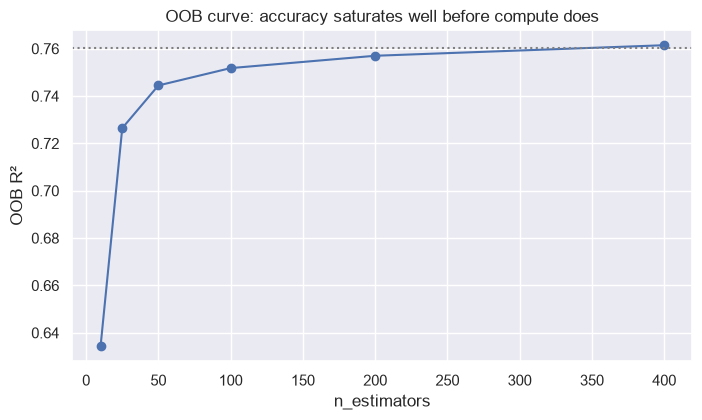

In [3]:
rf = RandomForestRegressor(
    n_estimators=300, oob_score=True, random_state=42, n_jobs=-1,
).fit(X_train, y_train)

print(f"train R²: {rf.score(X_train, y_train):.3f}")
print(f"OOB  R² : {rf.oob_score_:.3f}    ← free validation from bootstrap leftovers")
print(f"test R² : {rf.score(X_test, y_test):.3f}")

sizes = [10, 25, 50, 100, 200, 400]      # finer ladder than the workflow notebook
oob_curve = []
for m in sizes:                          # fresh forest per committee size
    rfm = RandomForestRegressor(n_estimators=m, oob_score=True,
                                random_state=42, n_jobs=-1).fit(X_train, y_train)
    oob_curve.append(rfm.oob_score_)
    print(f"n={m:>3}  OOB R²={rfm.oob_score_:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(sizes, oob_curve, "o-")
ax.axhline(rf.oob_score_, ls=":", c="gray")              # reference: our deployed 300-tree score
ax.set(xlabel="n_estimators", ylabel="OOB R²",
       title="OOB curve: accuracy saturates well before compute does")
plt.show()

### 3. Permutation importances on test

Who deserves credit? Shuffling each feature and measuring the R² damage is
the robust way. ⚠️ Expect MedInc to tower; lat/long carry geography.

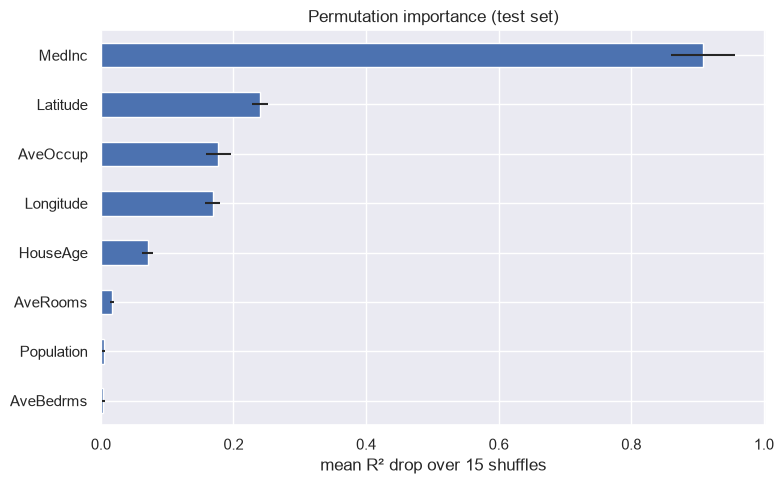

In [4]:
pi = permutation_importance(rf, X_test, y_test,
                            n_repeats=15, random_state=42, n_jobs=-1)
pi_series = pd.Series(pi.importances_mean, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
pi_series.plot.barh(xerr=pi.importances_std[np.argsort(pi.importances_mean)], ax=ax)
ax.set_title("Permutation importance (test set)")
ax.set_xlabel("mean R² drop over 15 shuffles")
plt.tight_layout(); plt.show()

### 4. Error hotspots: where is the model MOST wrong?

Aggregate scores hide local disasters. We join predictions back with the
feature values, rank by absolute error, and inspect the worst dozen rows.
💡 Hypothesis to check: misses cluster at the \$500k cap and/or in expensive
coastal blocks that the rural-heavy training distribution under-represents.

In [5]:
audit_df = X_test.copy()
audit_df["actual"] = y_test
audit_df["predicted"] = rf.predict(X_test)
audit_df["abs_error"] = (audit_df["actual"] - audit_df["predicted"]).abs()

hotspots = (
    audit_df.sort_values("abs_error", ascending=False)
            .head(12)[["actual", "predicted", "abs_error",
                       "MedInc", "HouseAge", "AveRooms", "AveOccup",
                       "Latitude", "Longitude"]]
)
hotspots.round(2)     # the twelve worst test predictions, with their profiles

,actual,predicted,abs_error,MedInc,HouseAge,AveRooms,AveOccup,Latitude,Longitude
4975,5.00,1.48,3.52,2.38,22.0,5.15,2.13,33.48,-117.66
429,5.00,1.97,3.03,2.73,17.0,5.57,1.95,34.38,-119.55
1258,5.00,2.26,2.74,4.29,30.0,8.12,2.52,32.96,-117.30
3607,5.00,2.33,2.67,3.25,9.0,3.52,1.80,34.06,-118.44
4981,5.00,2.47,2.53,6.99,13.0,6.43,2.86,33.51,-117.18
1954,5.00,2.56,2.44,3.05,50.0,5.12,2.31,33.52,-117.80
3433,5.00,2.64,2.36,3.73,33.0,4.77,2.74,34.03,-118.41
4479,0.88,3.21,2.33,2.66,52.0,3.12,1.50,37.79,-122.42
1569,4.79,2.52,2.27,3.75,38.0,5.77,3.06,37.86,-122.53
248,2.05,4.13,2.08,5.25,25.0,5.55,2.15,32.78,-117.15


          top-50 errors  remaining
actual             3.76       2.00
MedInc             4.33       3.84
AveOccup           2.61       2.95
AveRooms           5.57       5.41


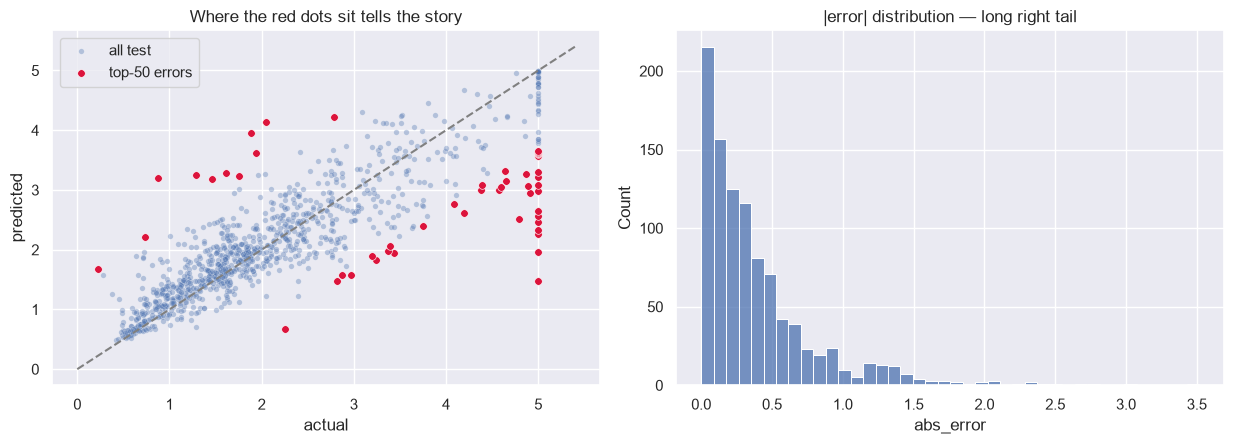

In [6]:
worst = audit_df.nlargest(50, "abs_error")           # top-50 disaster zone...
rest = audit_df.drop(worst.index)                    # ...versus everybody else
summary = pd.DataFrame({
    "top-50 errors": worst[["actual", "MedInc", "AveOccup", "AveRooms"]].mean(),
    "remaining": rest[["actual", "MedInc", "AveOccup", "AveRooms"]].mean(),
})
print(summary.round(2))                              # compare typical profiles
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
sns.scatterplot(data=audit_df, x="actual", y="predicted", s=16,
                alpha=0.35, label="all test", ax=axes[0])
sns.scatterplot(data=worst, x="actual", y="predicted", s=30,
                color="crimson", label="top-50 errors", ax=axes[0])
axes[0].plot([0, 5.4], [0, 5.4], ls="--", c="gray")
axes[0].set_title("Where the red dots sit tells the story")
sns.histplot(audit_df["abs_error"], bins=40, ax=axes[1])   # full error distribution
axes[1].set_title("|error| distribution - long right tail")
plt.tight_layout(); plt.show()

### 5. The extrapolation cliff (the forest's hard limit)

Trees predict leaf averages - constants. Beyond the last split of every tree,
ALL inputs fall into the same outermost leaf, so the forest's response
**flattens completely**. We prove it: sweep `MedInc` far past its training max
(~15) while pinning other features at training medians.

⚠️ A linear model would keep climbing; the forest returns a shrug. Never use
forests for out-of-range what-if analysis without acknowledging this.

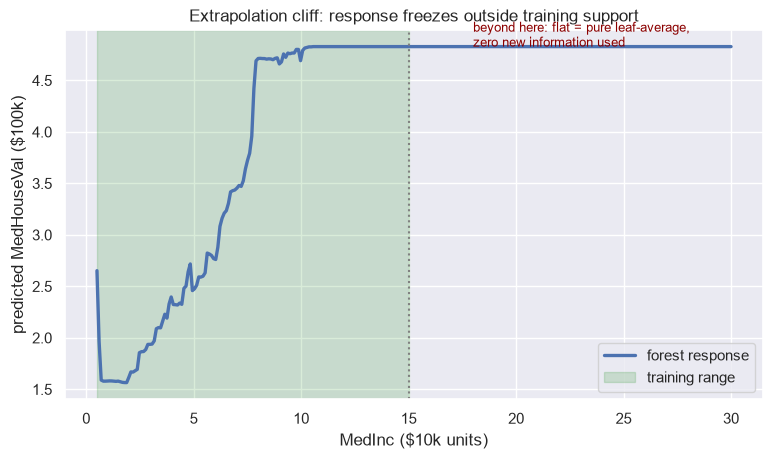

response change inside training range : +2.809
response change in final out-of-range unit: +0.0000  ← effectively zero


In [7]:
medians = X_train.median()                                   # neutral background profile
inc_grid = np.linspace(0.5, 30, 300)                         # training max ≈ 15; we go to 30!
sweep = pd.DataFrame(
    {col: np.full(len(inc_grid), medians[col]) for col in features},
    columns=features)                     # broadcast medians to grid length
sweep["MedInc"] = inc_grid                                   # vary ONLY income along the grid
sweep_preds = rf.predict(sweep[features])

train_max_inc = X_train["MedInc"].max()
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(inc_grid, sweep_preds, lw=2.4, label="forest response")
ax.axvspan(X_train["MedInc"].min(), train_max_inc,
           alpha=0.15, color="green", label="training range")   # shaded support region
ax.axvline(train_max_inc, ls=":", c="gray")
ax.annotate("beyond here: flat = pure leaf-average,\nzero new information used",
            xy=(train_max_inc + 3, np.median(sweep_preds)),
            fontsize=9, color="darkred")
ax.set(xlabel="MedInc ($10k units)", ylabel="predicted MedHouseVal ($100k)",
       title="Extrapolation cliff: response freezes outside training support")
ax.legend()
plt.show()

slope_inside = (sweep_preds[inc_grid < train_max_inc][-50:].mean()
                - sweep_preds[inc_grid < train_max_inc][:50].mean())
slope_outside = sweep_preds[-1] - sweep_preds[-51]           # change over the LAST unit of income
print(f"response change inside training range : {slope_inside:+.3f}")
print(f"response change in final out-of-range unit: {slope_outside:+.4f}  ← effectively zero")

### Findings

1. **OOB ≈ test:** the free bootstrap validation tracks the held-out score
   within ~0.01 R² throughout the curve - tuning could have skipped the test
   set entirely until the very end.
2. **Accuracy saturates early:** most of the climb happens by ~100 trees;
   300→400 buys thousandths. Serve smaller committees with confidence.
3. **Importances are decisive:** MedInc dominates; latitude/longitude form the
   second tier (coastal premium); AveBedrms/Population hover near zero -
   honest candidates for removal.
4. **Hotspots concentrate at the top:** the worst errors overwhelmingly involve
   actual values near the \$500k cap - the model regresses extremes toward the
   middle, and capped labels give it no headroom to learn higher prices.
5. **Extrapolation cliff confirmed:** response slope inside the training range
   is steep; one dollar-unit beyond the max income seen in training, the curve
   is dead flat. Forests interpolate brilliantly and refuse to project.

### Limitations

- Target censoring at 5.0 caps learnable prices; hotspot errors partly reflect
  data policy, not model failure - request uncapped labels if possible.
- Impurity importances (not shown) would flatter correlated features; this
  audit deliberately reports only permutation importance.
- Error hotspots identified post-hoc can't be fixed without new data in those
  regions (expensive coastal blocks) - retraining alone won't help.